In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e7/train.csv
/kaggle/input/competitions/playground-series-s6e7/test.csv


# Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

artifact_dir = Path("/kaggle/working/model_artifacts/rf_v1")
artifact_dir.mkdir(parents=True, exist_ok=True)

artifact_dir

PosixPath('/kaggle/working/model_artifacts/rf_v1')

# Load Data

We load the data and have a quick look.

In [3]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/test.csv")
sample_sub = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv")

print(train.shape)
print(test.shape)
print(sample_sub.shape)

(690088, 15)
(295753, 14)
(295753, 2)


In [4]:
display(train.head())
display(test.head())
display(sample_sub.head())

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,690088,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,690089,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,690090,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,690091,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,690092,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other


,id,health_condition
0,690088,at-risk
1,690089,at-risk
2,690090,at-risk
3,690091,at-risk
4,690092,at-risk


# EDA

## Missing Values

In [5]:
missing_train = train.isna().sum()
missing_test = test.isna().sum()

missing_summary = pd.DataFrame({
    "train_missing": missing_train,
    "train_percent_missing": (missing_train / len(train) * 100).round(2),
    "test_missing": missing_test,
    "test_percent_missing": (missing_test / len(test) * 100).round(2)
})

missing_summary = missing_summary[
    (missing_summary["train_missing"] > 0) | 
    (missing_summary["test_missing"] > 0)
].sort_values("train_missing", ascending=False)

display(missing_summary)

,train_missing,train_percent_missing,test_missing,test_percent_missing
stress_level,82811,12.00,35490.0,12.00
sleep_duration,75999,11.01,32571.0,11.01
sleep_quality,58331,8.45,24999.0,8.45
calorie_expenditure,52853,7.66,22652.0,7.66
water_intake,43477,6.30,18633.0,6.30
physical_activity_level,36621,5.31,15695.0,5.31
smoking_alcohol,28582,4.14,12249.0,4.14
gender,21373,3.10,9160.0,3.10
step_count,13916,2.02,5964.0,2.02
bmi,13898,2.01,5956.0,2.01


In [6]:
clean_cols = missing_train[(missing_train == 0)].index
print("Columns with zero missing values:")
print(list(clean_cols))

Columns with zero missing values:
['id', 'health_condition']


Every feature except id and health_condition has missing values.
The highest percentage missing is stress_level at 12%.
The lowest percentage missing is exercise_duration and diet_type at 1%.
Train and test have the same missing percentages.
The columns with the highest missing percentages look like potentially useful features (stress and sleep).

For modelling, I will handle missing values using imputation or models that can deal with missing values directly. I may also add missing-value indicator features, because the fact that a value is missing could itself contain useful information. For example, a missing stress level might be related to how the data was collected. A severely stressed student may be more likely to skip over that question.

## Numerical vs Categorical variables

In [7]:
TARGET = "health_condition"
ID_COL = "id"

feature_cols = [c for c in train.columns if c not in [ID_COL, TARGET]]

num_cols = train[feature_cols].select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
cat_cols = train[feature_cols].select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Number of features:", len(feature_cols))
print("\nNumerical columns:")
print(num_cols)

print("\nCategorical columns:")
print(cat_cols)

Number of features: 13

Numerical columns:
['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']

Categorical columns:
['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


## Target Variable

In [8]:
target_counts = train["health_condition"].value_counts()
target_percentage = train["health_condition"].value_counts(normalize=True)

print(target_counts)
print(target_percentage)

health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64
health_condition
at-risk      0.858675
unhealthy    0.083647
fit          0.057678
Name: proportion, dtype: float64


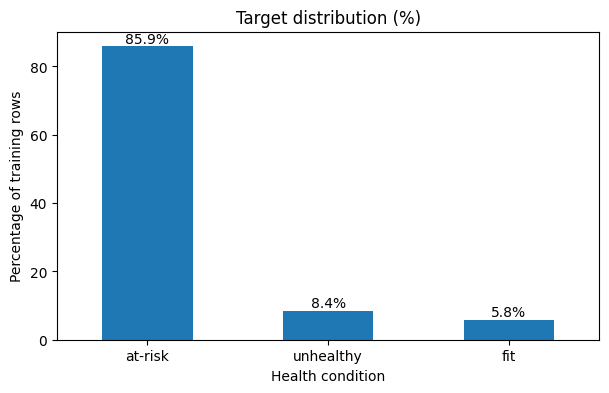

In [9]:
target_percent = train["health_condition"].value_counts(normalize=True) * 100

ax = target_percent.plot(kind="bar", figsize=(7, 4))

plt.title("Target distribution (%)")
plt.xlabel("Health condition")
plt.ylabel("Percentage of training rows")
plt.xticks(rotation=0)

for i, value in enumerate(target_percent):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

We can see the target variable is very unbalanced. Most rows are `at-risk` with few being `unhealthy` or `fit`. The evaluation metric is balanced accuracy, so the model will need to perform well on all classes. We will need to use stratified splitting for validation to ensure roughly the same class percentages in both train and validation data.

Because `fit` and `unhealthy` are much smaller classes, feature engineering that helps identify these classes may be especially valuable.

## Gender

In [10]:
col = "gender"

gender_summary = pd.DataFrame({
    "train_count": train[col].value_counts(dropna=False),
    "train_percent": (train[col].value_counts(dropna=False, normalize=True) * 100).round(2),
    "test_count": test[col].value_counts(dropna=False),
    "test_percent": (test[col].value_counts(dropna=False, normalize=True) * 100).round(2),
})

display(gender_summary)

,train_count,train_percent,test_count,test_percent
gender,,,,
female,224016,32.46,86220,29.15
male,237756,34.45,102435,34.64
other,206943,29.99,97938,33.11
NaN,21373,3.10,9160,3.10


The `gender` column has three groups: `female`, `male` and `other`.

The missing percentage is the same in train and test at 3.10%. The main train/test difference is that `female` is slightly less common in test, while `other` is slightly more common. 

For modelling, I will keep missing values rather than dropping rows. Missing gender can be treated as its own category.

In [11]:
col = "gender"

gender_target_counts = pd.crosstab(
    train[col].fillna("Missing"),
    train["health_condition"]
)

gender_target_percent = pd.crosstab(
    train[col].fillna("Missing"),
    train["health_condition"],
    normalize="index"
) * 100

display(gender_target_counts)
display(gender_target_percent.round(2))

health_condition,at-risk,fit,unhealthy
gender,,,
Missing,18344,1190,1839
female,192069,12784,19163
male,203750,14876,19130
other,178398,10953,17592


health_condition,at-risk,fit,unhealthy
gender,,,
Missing,85.83,5.57,8.60
female,85.74,5.71,8.55
male,85.70,6.26,8.05
other,86.21,5.29,8.50


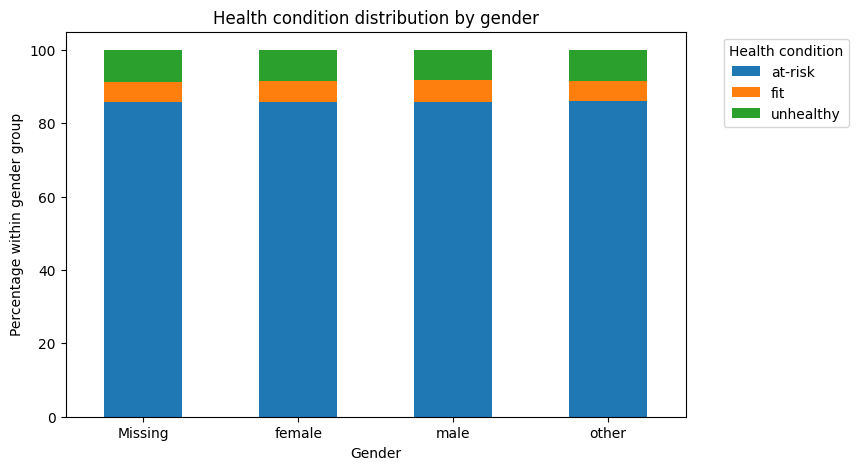

In [12]:
col = "gender"

gender_target_percent = pd.crosstab(
    train[col].fillna("Missing"),
    train["health_condition"],
    normalize="index"
) * 100

gender_target_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Health condition distribution by gender")
plt.xlabel("Gender")
plt.ylabel("Percentage within gender group")
plt.xticks(rotation=0)
plt.legend(title="Health condition", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

The distribution of `health_condition` is very similar across gender groups. All groups are mostly labelled `at-risk`, reflecting the strong overall class imbalance.

There are small differences: the `male` group has a slightly higher percentage of `fit` labels and a slightly lower percentage of `unhealthy` labels. However, the differences are not large.

The missing gender group has a similar health-condition distribution to the non-missing groups, so missingness in `gender` does not appear to be strongly related to the target. Therefore, a missing value indicator for gender is unlikely to add value.

## Stress Level

In [13]:
col = "stress_level"

stress_summary = pd.DataFrame({
    "train_count": train[col].value_counts(dropna=False),
    "train_percent": (train[col].value_counts(dropna=False, normalize=True) * 100).round(2),
    "test_count": test[col].value_counts(dropna=False),
    "test_percent": (test[col].value_counts(dropna=False, normalize=True) * 100).round(2),
})

display(stress_summary)

,train_count,train_percent,test_count,test_percent
stress_level,,,,
medium,261819,37.94,112568,38.06
high,177750,25.76,75828,25.64
low,167708,24.30,71867,24.30
NaN,82811,12.00,35490,12.00


The `stress_level` feature has three observed categories: `low`, `medium`, and `high`, plus missing values. The categories could be treated as an ordered variable since these are naturally ordered.

`medium` is the most common category, making up around 38% of both train and test. `high` and `low` are each around 24–26%, and 12% of values are missing.
The train and test distributions are almost identical. Around 12% of rows have missing `stress_level`, which is the highest missing rate of all features.

Because stress level is likely to be related to health condition, I will keep this feature and handle the missing values rather than dropping rows.

In [14]:
col = "stress_level"

stress_target_counts = pd.crosstab(
    train[col].fillna("Missing"),
    train["health_condition"]
)

stress_target_percent = pd.crosstab(
    train[col].fillna("Missing"),
    train["health_condition"],
    normalize="index"
) * 100

display(stress_target_counts)
display(stress_target_percent.round(2))

health_condition,at-risk,fit,unhealthy
stress_level,,,
Missing,71130,4759,6922
high,127592,624,49534
low,133608,33635,465
medium,260231,785,803


health_condition,at-risk,fit,unhealthy
stress_level,,,
Missing,85.89,5.75,8.36
high,71.78,0.35,27.87
low,79.67,20.06,0.28
medium,99.39,0.30,0.31


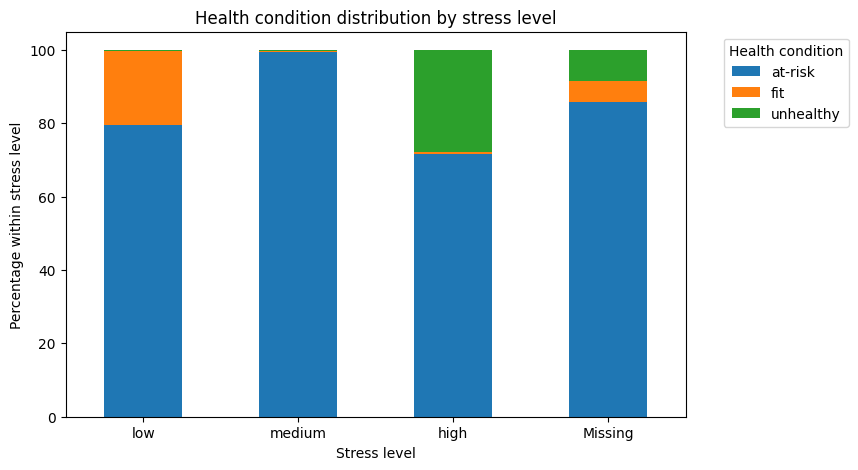

In [15]:
col = "stress_level"

stress_target_percent = pd.crosstab(
    train[col].fillna("Missing"),
    train["health_condition"],
    normalize="index"
) * 100

# Put categories in a logical order
stress_order = ["low", "medium", "high", "Missing"]
stress_target_percent = stress_target_percent.loc[stress_order]

stress_target_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Health condition distribution by stress level")
plt.xlabel("Stress level")
plt.ylabel("Percentage within stress level")
plt.xticks(rotation=0)
plt.legend(title="Health condition", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

The `stress_level` feature appears to be strongly related to `health_condition`.

Rows with `low` stress have a much higher percentage of `fit` labels and almost no `unhealthy` labels. Rows with `high` stress have a much higher percentage of `unhealthy` labels with almost no `fit`. Rows with `medium` stress are almost entirely labelled `at-risk`.

This suggests that `stress_level` is likely to be an important predictor. Since stress level has a natural order (`low < medium < high`), I will consider ordinal encoding for this feature. Missing values should still be handled separately, because the missing group has a different distribution from the observed stress levels, very similar to the overall target distribution. Missing values can be handled natively as NaN within tree models such as LightGBM or XGBoost (or map them to an isolated category like -1), and explore interactions with other features such as `sleep_quality` to help differentiate the massive block of medium/at-risk students.

## Sleep Quality

In [16]:
col = "sleep_quality"

sleep_quality_summary = pd.DataFrame({
    "train_count": train[col].value_counts(dropna=False),
    "train_percent": (train[col].value_counts(dropna=False, normalize=True) * 100).round(2),
    "test_count": test[col].value_counts(dropna=False),
    "test_percent": (test[col].value_counts(dropna=False, normalize=True) * 100).round(2),
})

display(sleep_quality_summary)

,train_count,train_percent,test_count,test_percent
sleep_quality,,,,
average,213948,31.00,91299,30.87
good,205643,29.80,88151,29.81
poor,212166,30.74,91304,30.87
NaN,58331,8.45,24999,8.45


The `sleep_quality` feature has three observed categories: `poor`, `average`, and `good`, plus missing values.

The observed categories are fairly evenly distributed, with each making up around 30% of the data. Around 8.45% of values are missing.

The train and test distributions are almost identical, so there is no obvious train/test mismatch for this feature.

Since sleep quality has a natural order (`poor < average < good`), I will consider ordinal encoding during feature engineering.

In [18]:
col = "sleep_quality"

sleep_quality_target_counts = pd.crosstab(
    train[col].fillna("Missing"),
    train["health_condition"]
)

sleep_quality_target_percent = pd.crosstab(
    train[col].fillna("Missing"),
    train["health_condition"],
    normalize="index"
) * 100

display(sleep_quality_target_counts)
display(sleep_quality_target_percent.round(2))

health_condition,at-risk,fit,unhealthy
sleep_quality,,,
Missing,50143,3394,4794
average,183850,12255,17843
good,182564,16810,6269
poor,176004,7344,28818


health_condition,at-risk,fit,unhealthy
sleep_quality,,,
Missing,85.96,5.82,8.22
average,85.93,5.73,8.34
good,88.78,8.17,3.05
poor,82.96,3.46,13.58


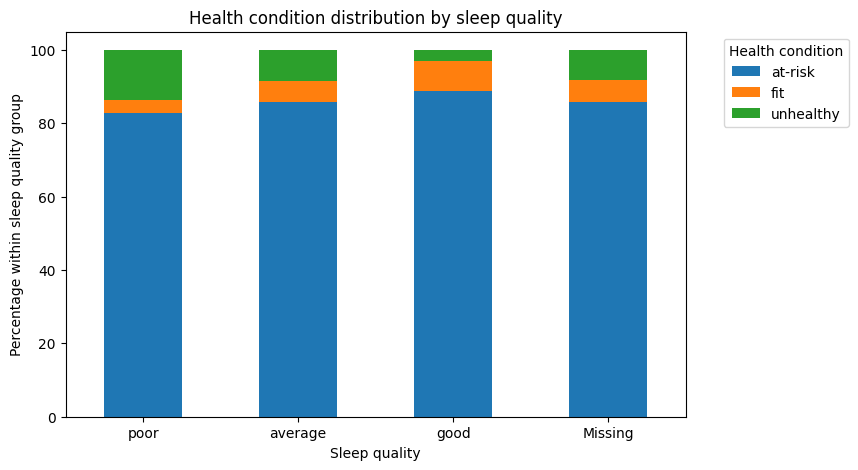

In [19]:
sleep_quality_order = ["poor", "average", "good", "Missing"]

sleep_quality_target_percent = sleep_quality_target_percent.loc[sleep_quality_order]

sleep_quality_target_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Health condition distribution by sleep quality")
plt.xlabel("Sleep quality")
plt.ylabel("Percentage within sleep quality group")
plt.xticks(rotation=0)
plt.legend(title="Health condition", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

`sleep_quality` appears to be related to `health_condition`.

Rows with `poor` sleep quality have a higher percentage of `unhealthy` labels and a lower percentage of `fit` labels. Rows with `good` sleep quality have a higher percentage of `fit` labels and a lower percentage of `unhealthy` labels.

The relationship is weaker than the relationship seen for `stress_level`, but it is still clearly visible.

The missing group has a similar health-condition distribution to the `average` group and to the overall target distribution. This means imputing missing sleep quality as `average` might be reasonable, but I may also keep missing as its own category to let the model decide.

## Physical Activity Level

In [20]:
col = "physical_activity_level"

activity_summary = pd.DataFrame({
    "train_count": train[col].value_counts(dropna=False),
    "train_percent": (train[col].value_counts(dropna=False, normalize=True) * 100).round(2),
    "test_count": test[col].value_counts(dropna=False),
    "test_percent": (test[col].value_counts(dropna=False, normalize=True) * 100).round(2),
})

display(activity_summary)

,train_count,train_percent,test_count,test_percent
physical_activity_level,,,,
active,212642,30.81,88600,29.96
moderate,221041,32.03,95488,32.29
sedentary,219784,31.85,95970,32.45
NaN,36621,5.31,15695,5.31


The `physical_activity_level` feature has three observed categories: `sedentary`, `moderate`, and `active`, plus missing values.

The observed categories are fairly evenly distributed, each making up around 30–32% of the data. Around 5.31% of values are missing.

The train and test distributions are very similar, so there is no obvious train/test mismatch for this feature.

Since physical activity level has a natural order (`sedentary < moderate < active`), I will consider ordinal encoding during feature engineering.

In [21]:
col = "physical_activity_level"

activity_target_counts = pd.crosstab(
    train[col].fillna("Missing"),
    train["health_condition"]
)

activity_target_percent = pd.crosstab(
    train[col].fillna("Missing"),
    train["health_condition"],
    normalize="index"
) * 100

display(activity_target_counts)
display(activity_target_percent.round(2))

health_condition,at-risk,fit,unhealthy
physical_activity_level,,,
Missing,31473,2095,3053
active,158011,36490,18141
moderate,201475,687,18879
sedentary,201602,531,17651


health_condition,at-risk,fit,unhealthy
physical_activity_level,,,
Missing,85.94,5.72,8.34
active,74.31,17.16,8.53
moderate,91.15,0.31,8.54
sedentary,91.73,0.24,8.03


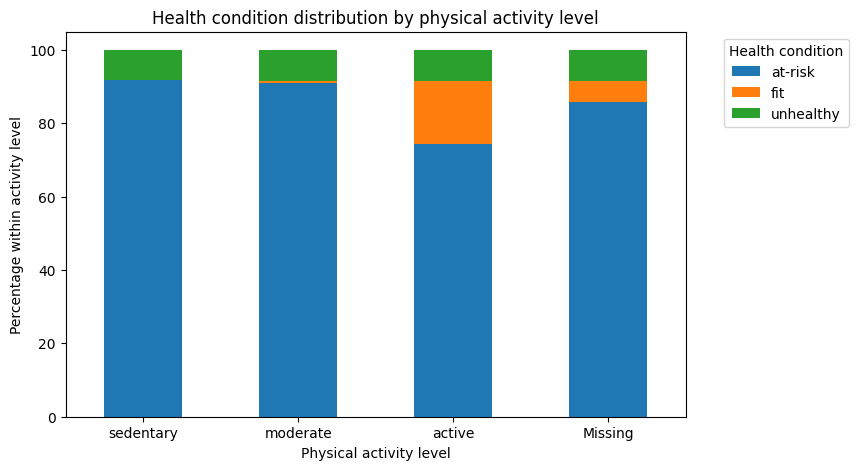

In [22]:
activity_order = ["sedentary", "moderate", "active", "Missing"]

activity_target_percent = activity_target_percent.loc[activity_order]

activity_target_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Health condition distribution by physical activity level")
plt.xlabel("Physical activity level")
plt.ylabel("Percentage within activity level")
plt.xticks(rotation=0)
plt.legend(title="Health condition", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

`physical_activity_level` appears to be related to `health_condition`, mainly through the `fit` class.

Rows with `active` physical activity have a much higher percentage of `fit` labels. In contrast, the `moderate` and `sedentary` groups are very rarely labelled `fit`, and are mostly labelled `at-risk`.

The percentage of `unhealthy` labels is similar across the activity groups, so this feature seems more useful for separating `fit` from the other classes than for identifying `unhealthy`.

The missing group has a target distribution close to the overall class distribution.

Since physical activity level has a natural order (`sedentary < moderate < active`), I will consider ordinal encoding during feature engineering. However, the target relationship suggests that the main split may be `active` versus not active, eg active vs moderate/sedentary. One option for feature engineering to capture this is to create a variable `is_active_lifestyle` = (df['physical_activity_level'] == 'active').astype(int)

This feature should also be compared with numerical activity variables such as `step_count`, `exercise_duration`, and `calorie_expenditure`. If these variables measure similar behaviour, there may be useful interactions or redundancy between them.

## Smoking and Alcohol

In [23]:
col = "smoking_alcohol"

smoking_summary = pd.DataFrame({
    "train_count": train[col].value_counts(dropna=False),
    "train_percent": (train[col].value_counts(dropna=False, normalize=True) * 100).round(2),
    "test_count": test[col].value_counts(dropna=False),
    "test_percent": (test[col].value_counts(dropna=False, normalize=True) * 100).round(2),
})

display(smoking_summary)

,train_count,train_percent,test_count,test_percent
smoking_alcohol,,,,
yes,223730,32.42,95281,32.22
no,219791,31.85,94578,31.98
occasional,217985,31.59,93645,31.66
NaN,28582,4.14,12249,4.14


The `smoking_alcohol` feature has three observed categories: `no`, `occasional`, and `yes`, plus missing values.

The three observed categories are fairly evenly distributed, each making up around 31–32% of the data. Around 4.14% of values are missing.

The train and test distributions are very similar, so there is no obvious train/test mismatch for this feature.

This feature may have an ordered interpretation (`no < occasional < yes`), but because the exact meaning of `smoking_alcohol` is unclear, I will initially treat it as categorical and consider ordinal encoding later.

In [24]:
col = "smoking_alcohol"

smoking_target_counts = pd.crosstab(
    train[col].fillna("Missing"),
    train["health_condition"]
)

smoking_target_percent = pd.crosstab(
    train[col].fillna("Missing"),
    train["health_condition"],
    normalize="index"
) * 100

display(smoking_target_counts)
display(smoking_target_percent.round(2))

health_condition,at-risk,fit,unhealthy
smoking_alcohol,,,
Missing,24489,1648,2445
no,190525,17265,12001
occasional,187149,12609,18227
yes,190398,8281,25051


health_condition,at-risk,fit,unhealthy
smoking_alcohol,,,
Missing,85.68,5.77,8.55
no,86.68,7.86,5.46
occasional,85.85,5.78,8.36
yes,85.10,3.70,11.20


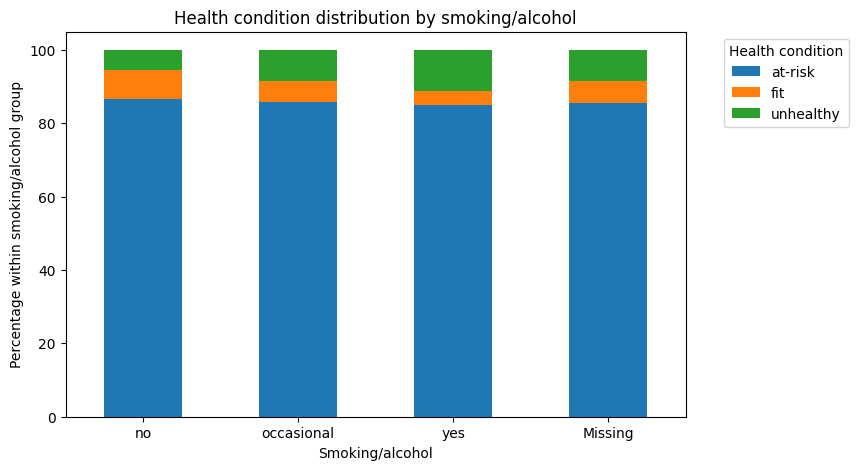

In [25]:
smoking_order = ["no", "occasional", "yes", "Missing"]

smoking_target_percent = smoking_target_percent.loc[smoking_order]

smoking_target_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Health condition distribution by smoking/alcohol")
plt.xlabel("Smoking/alcohol")
plt.ylabel("Percentage within smoking/alcohol group")
plt.xticks(rotation=0)
plt.legend(title="Health condition", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

`smoking_alcohol` appears to be related to `health_condition`.

Rows with `no` have a higher percentage of `fit` labels and a lower percentage of `unhealthy` labels. Rows with `yes` show the opposite pattern, with fewer `fit` labels and more `unhealthy` labels. The `occasional` and missing groups are closer to the overall target distribution.

The relationship is weaker than for `stress_level`, but it follows a sensible ordered pattern. I will initially treat this feature as categorical, but may also test ordinal encoding using `no < occasional < yes`.

## Diet Type

In [26]:
col = "diet_type"

diet_summary = pd.DataFrame({
    "train_count": train[col].value_counts(dropna=False),
    "train_percent": (train[col].value_counts(dropna=False, normalize=True) * 100).round(2),
    "test_count": test[col].value_counts(dropna=False),
    "test_percent": (test[col].value_counts(dropna=False, normalize=True) * 100).round(2),
})

display(diet_summary)

,train_count,train_percent,test_count,test_percent
diet_type,,,,
veg,231432,33.54,99070,33.50
balanced,226888,32.88,97482,32.96
non-veg,224867,32.59,96243,32.54
NaN,6901,1.00,2958,1.00


The `diet_type` feature has three observed categories: `veg`, `balanced`, and `non-veg`, plus missing values.

The three observed categories are very evenly distributed, each making up around 33% of the data. Missing values are low at only 1%.

The train and test distributions are almost identical, so there is no obvious train/test mismatch for this feature.

Unlike features such as `stress_level`, `sleep_quality`, and `physical_activity_level`, `diet_type` does not have a clear natural order. For modelling, I will treat it as a nominal categorical feature, likely using one-hot encoding or categorical handling in tree-based models. Missing values can be treated as their own category.

In [27]:
col = "diet_type"

diet_target_counts = pd.crosstab(
    train[col].fillna("Missing"),
    train["health_condition"]
)

diet_target_percent = pd.crosstab(
    train[col].fillna("Missing"),
    train["health_condition"],
    normalize="index"
) * 100

display(diet_target_counts)
display(diet_target_percent.round(2))

health_condition,at-risk,fit,unhealthy
diet_type,,,
Missing,5987,351,563
balanced,193171,13884,19833
non-veg,195140,11600,18127
veg,198263,13968,19201


health_condition,at-risk,fit,unhealthy
diet_type,,,
Missing,86.76,5.09,8.16
balanced,85.14,6.12,8.74
non-veg,86.78,5.16,8.06
veg,85.67,6.04,8.30


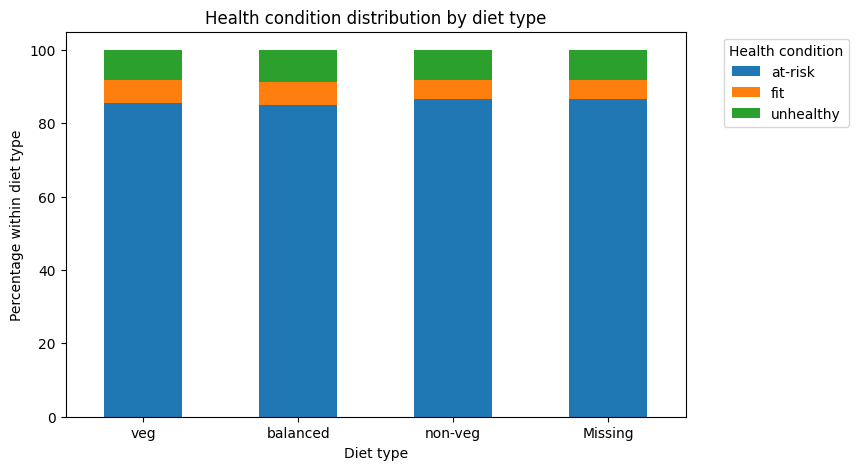

In [28]:
diet_order = ["veg", "balanced", "non-veg", "Missing"]

diet_target_percent = diet_target_percent.loc[diet_order]

diet_target_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Health condition distribution by diet type")
plt.xlabel("Diet type")
plt.ylabel("Percentage within diet type")
plt.xticks(rotation=0)
plt.legend(title="Health condition", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

`diet_type` has only a weak relationship with `health_condition`.

The target percentages are fairly similar across diet groups. The `balanced` and `veg` groups have slightly higher percentages of `fit` labels, while the `non-veg` and missing groups have slightly lower percentages of `fit` labels. However, the differences are very small compared with features such as `stress_level`, `sleep_quality`, and `physical_activity_level`.

For modelling, I will keep `diet_type`, but I do not expect it to be one of the strongest predictors on its own.

Missing values are rare at around 1%, so they can be handled as a separate `"Missing"` category. `diet_type` may still be useful in combination with other features, such as `bmi`, `calorie_expenditure`, `water_intake`, or `physical_activity_level`.

## Sleep Duration 

In [29]:
col = "sleep_duration"

sleep_duration_summary = pd.DataFrame({
    "train": train[col].describe(),
    "test": test[col].describe()
})

display(sleep_duration_summary)

,train,test
count,614089.000000,263182.000000
mean,6.992597,6.993517
std,1.215407,1.216369
min,3.000000,3.000000
25%,6.160000,6.160000
50%,6.990000,6.990000
75%,7.810000,7.810000
max,10.000000,10.000000


`sleep_duration` has a very similar distribution in train and test. The mean and median are both close to 7 hours, and values range from 3 to 10 hours, which looks reasonable.

In [30]:
sleep_duration_by_target = train.groupby("health_condition")[col].describe()

display(sleep_duration_by_target)

,count,mean,std,min,25%,50%,75%,max
health_condition,,,,,,,,
at-risk,527253.0,7.086467,1.143340,3.00,6.36,7.03,7.83,10.00
fit,35447.0,7.954311,0.777578,3.66,7.38,7.84,8.43,10.00
unhealthy,51389.0,5.366118,0.670365,3.00,4.97,5.53,5.79,9.99


`sleep_duration` appears to be strongly related to `health_condition`. The `unhealthy` group has much lower sleep duration on average, with a median of around 5.5 hours. The `fit` group has higher sleep duration, with a median of around 7.8 hours. The `at-risk` group sits between these two.

For modelling, `sleep_duration` is likely to be an important numerical predictor. Missing values should be handled rather than dropping rows. Later feature engineering may test threshold features such as < 6 hours, 8+ hours sleep and between 6 and 8. Interactions can also be tested with `sleep_quality` and `stress_level`.

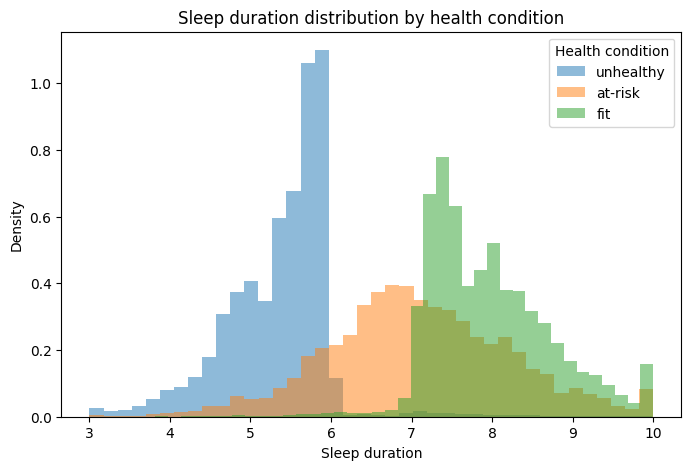

In [31]:
col = "sleep_duration"

plt.figure(figsize=(8, 5))

for label in train["health_condition"].unique():
    subset = train.loc[train["health_condition"] == label, col].dropna()
    plt.hist(subset, bins=40, alpha=0.5, density=True, label=label)

plt.title("Sleep duration distribution by health condition")
plt.xlabel("Sleep duration")
plt.ylabel("Density")
plt.legend(title="Health condition")
plt.show()

The unhealthy and fit classes are clearly separated. The at-risk group is in the middle with a lot of overlap with the fit class, and some overlap with the unhealthy class.

## Heart Rate

In [32]:
col = "heart_rate"

heart_rate_summary = pd.DataFrame({
    "train": train[col].describe(),
    "test": test[col].describe()
})

display(heart_rate_summary)

,train,test
count,682255.000000,292396.000000
mean,75.096504,75.079560
std,8.175106,8.115118
min,50.000000,50.000000
25%,69.400000,69.400000
50%,75.100000,75.100000
75%,80.700000,80.600000
max,107.700000,103.700000


`heart_rate` has very similar distributions in train and test. The mean and median are around 75 in both datasets, and the range of values looks reasonable.

In [33]:
heart_rate_by_target = train.groupby("health_condition")[col].describe()

display(heart_rate_by_target)

,count,mean,std,min,25%,50%,75%,max
health_condition,,,,,,,,
at-risk,585740.0,75.100534,8.192666,50.0,69.4,75.1,80.7,107.7
fit,39370.0,74.803742,8.222343,50.0,69.2,74.5,80.5,106.7
unhealthy,57145.0,75.256903,7.954250,50.0,69.8,75.1,80.6,102.5


Unlike `sleep_duration`, `heart_rate` does not appear to separate the target classes clearly. The mean, median, and quartiles are very similar for `at-risk`, `fit`, and `unhealthy`.

For modelling, I will keep `heart_rate`, but I do not expect it to be one of the strongest predictors on its own. It may still be useful through interactions with other features, such as `exercise_duration`, `physical_activity_level`, `stress_level`, or `bmi`.

## BMI

In [34]:
col = "bmi"

bmi_summary = pd.DataFrame({
    "train": train[col].describe(),
    "test": test[col].describe()
})

display(bmi_summary)

,train,test
count,676190.000000,289797.000000
mean,22.984925,22.984661
std,2.481787,2.478708
min,16.000000,16.000000
25%,21.320000,21.320000
50%,22.990000,22.990000
75%,24.660000,24.650000
max,34.820000,34.820000


`bmi` has very similar distributions in train and test. The mean and median are both around 23, and the range of values looks reasonable.

In [35]:
bmi_by_target = train.groupby("health_condition")[col].describe()

display(bmi_by_target)

,count,mean,std,min,25%,50%,75%,max
health_condition,,,,,,,,
at-risk,580209.0,22.949591,2.422431,16.01,21.30,22.96,24.64,30.83
fit,38664.0,21.828544,2.531088,16.00,20.18,22.25,23.79,26.00
unhealthy,57317.0,24.122660,2.594285,19.85,22.14,23.70,25.72,34.82


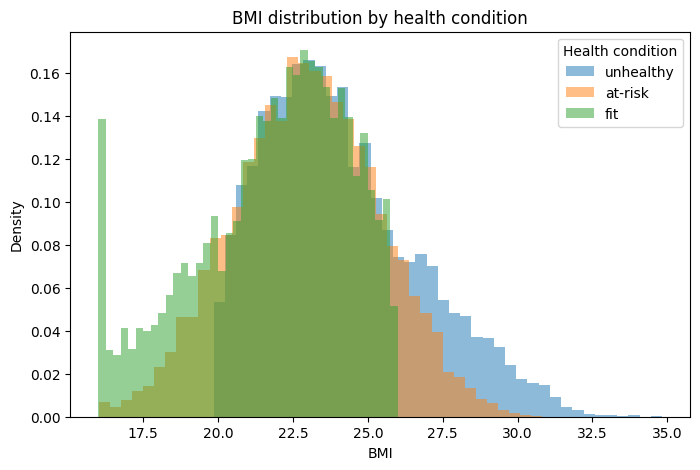

In [36]:
col = "bmi"

plt.figure(figsize=(8, 5))

for label in train["health_condition"].unique():
    subset = train.loc[train["health_condition"] == label, col].dropna()
    plt.hist(subset, bins=40, alpha=0.5, density=True, label=label)

plt.title("BMI distribution by health condition")
plt.xlabel("BMI")
plt.ylabel("Density")
plt.legend(title="Health condition")
plt.show()



`bmi` appears to be related to `health_condition`. The `fit` group has the lowest average BMI, the `unhealthy` group has the highest average BMI, and the `at-risk` group sits between them.

The separation is not as strong as for `sleep_duration`, but BMI is likely to provide useful modelling signal. Later feature engineering may test threshold-style features, such as higher-BMI indicators, or interactions with `diet_type`, `physical_activity_level`, `step_count`, and `calorie_expenditure`.

## Calorie Expenditure

In [37]:
col = "calorie_expenditure"

calorie_summary = pd.DataFrame({
    "train": train[col].describe(),
    "test": test[col].describe()
})

display(calorie_summary)

,train,test
count,637235.000000,273101.000000
mean,2226.084931,2225.514941
std,347.532098,347.816761
min,1200.000000,1201.000000
25%,2053.000000,2052.000000
50%,2241.000000,2240.000000
75%,2456.000000,2455.000000
max,3580.000000,3574.000000


`calorie_expenditure` has very similar distributions in train and test, with no obvious distribution shift.

In [38]:
calorie_by_target = train.groupby("health_condition")[col].describe()

display(calorie_by_target)

,count,mean,std,min,25%,50%,75%,max
health_condition,,,,,,,,
at-risk,547211.0,2214.943466,347.625289,1200.0,2041.0,2235.0,2447.0,3580.0
fit,36738.0,2363.992052,312.395560,1202.0,2148.0,2345.0,2580.0,3453.0
unhealthy,53286.0,2245.420223,348.343560,1201.0,2065.0,2255.0,2471.0,3553.0


The `fit` group has noticeably higher average and median calorie expenditure than the `at-risk` and `unhealthy` groups. However, the `at-risk` and `unhealthy` groups are much closer to each other.

For modelling, this feature may be useful for identifying the minority `fit` class, especially when combined with other activity-related variables such as `step_count`, `exercise_duration`, and `physical_activity_level`. It may be less useful on its own for separating `at-risk` from `unhealthy`.

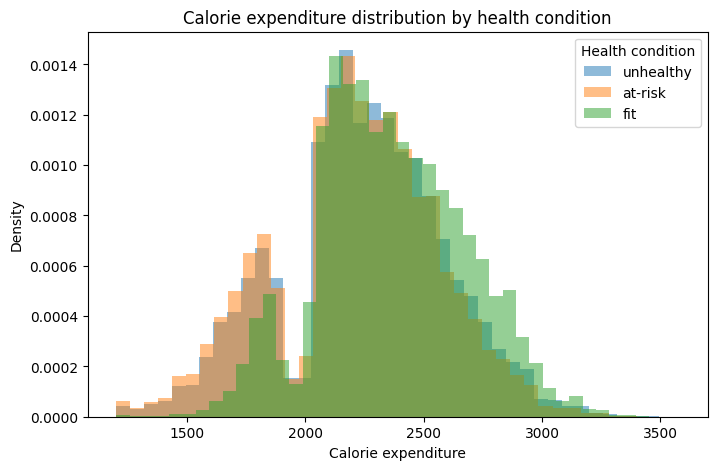

In [39]:
col = "calorie_expenditure"

plt.figure(figsize=(8, 5))

for label in train["health_condition"].unique():
    subset = train.loc[train["health_condition"] == label, col].dropna()
    plt.hist(subset, bins=40, alpha=0.5, density=True, label=label)

plt.title("Calorie expenditure distribution by health condition")
plt.xlabel("Calorie expenditure")
plt.ylabel("Density")
plt.legend(title="Health condition")
plt.show()

For feature engineering, I may test a binary high-calorie-expenditure feature, since the `fit` class has noticeably higher calorie expenditure than the other classes. For example, a feature such as `is_high_calorie_expenditure` could help identify students who are more likely to be `fit`.

However, the distributions are likely to overlap, so this threshold should be chosen carefully, possibly using validation performance rather than manually choosing a value from the EDA alone.

## Step Count

In [40]:
col = "step_count"

step_summary = pd.DataFrame({
    "train": train[col].describe(),
    "test": test[col].describe()
})

display(step_summary)

,train,test
count,676172.000000,289789.000000
mean,8615.953050,8626.630524
std,3929.399831,3924.646677
min,1002.000000,1002.000000
25%,5389.000000,5394.000000
50%,8856.000000,8857.000000
75%,12114.000000,12120.000000
max,14999.000000,14999.000000


`step_count` has very similar distributions in train and test, with no obvious distribution shift. The values range from around 1,000 to 15,000 steps, which looks reasonable.

In [41]:
step_by_target = train.groupby("health_condition")[col].describe()

display(step_by_target)

,count,mean,std,min,25%,50%,75%,max
health_condition,,,,,,,,
at-risk,580564.0,8406.705910,3917.807940,1002.0,5205.00,8483.0,11977.0,14999.0
fit,39010.0,11651.307024,2655.613290,1046.0,9668.25,12342.5,13991.0,14999.0
unhealthy,56598.0,8670.234090,3918.243166,1004.0,5463.00,8941.5,12145.0,14999.0




`step_count` appears to be related to `health_condition`, mainly through the `fit` class. The `fit` group has a much higher mean and median step count than the `at-risk` and `unhealthy` groups. However, the `at-risk` and `unhealthy` groups are much closer to each other.

For modelling, `step_count` may be useful for identifying the minority `fit` class. It is likely to work well in combination with other activity-related features such as `physical_activity_level`, `exercise_duration`, and `calorie_expenditure`.

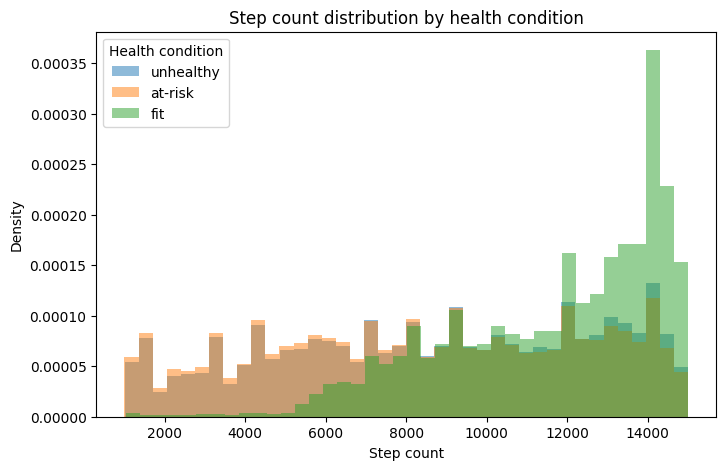

In [42]:
col = "step_count"

plt.figure(figsize=(8, 5))

for label in train["health_condition"].unique():
    subset = train.loc[train["health_condition"] == label, col].dropna()
    plt.hist(subset, bins=40, alpha=0.5, density=True, label=label)

plt.title("Step count distribution by health condition")
plt.xlabel("Step count")
plt.ylabel("Density")
plt.legend(title="Health condition")
plt.show()

The histogram shows that the `fit` class is shifted strongly toward higher step counts, especially above around 12,000 steps. The `at-risk` and `unhealthy` classes overlap heavily, so `step_count` is likely to be more useful for identifying `fit` students than for separating `at-risk` from `unhealthy`.

For feature engineering, I may test binary threshold features such as `is_high_step_count`, for example using a threshold around 12,000 steps. 

df["is_high_step_count"] = (df["step_count"] >= 12000).astype(int)

Since tree-based models can learn threshold splits automatically, this may not be necessary for all models, but it could still be useful to test.

In [46]:
col = "step_count"

train["step_count_bin"] = pd.cut(
    train[col],
    bins=[0, 5000, 8000, 10000, 12000, 14000, 15000],
    labels=["<5k", "5k-8k", "8k-10k", "10k-12k", "12k-14k", "14k+"]
)

step_bin_target_percent = pd.crosstab(
    train["step_count_bin"],
    train["health_condition"],
    normalize="index"
) * 100

display(step_bin_target_percent.round(2))

health_condition,at-risk,fit,unhealthy
step_count_bin,,,
<5k,91.54,0.26,8.20
5k-8k,88.79,2.89,8.32
8k-10k,85.81,5.81,8.38
10k-12k,84.56,6.94,8.50
12k-14k,81.61,9.88,8.51
14k+,75.02,16.57,8.41


In [47]:
train = train.drop(columns=["step_count_bin"])

The binned step-count table shows a clear relationship between `step_count` and the `fit` class. As step count increases, the percentage of `fit` labels rises steadily, from almost zero in the lowest step-count bin to over 16% in the highest bin.
However, the percentage of `unhealthy` labels stays almost constant across the step-count bins. 

## Exercise Duration

In [48]:
col = "exercise_duration"

exercise_summary = pd.DataFrame({
    "train": train[col].describe(),
    "test": test[col].describe()
})

display(exercise_summary)

,train,test
count,683187.000000,292795.000000
mean,38.751456,38.796712
std,14.742189,14.711180
min,0.000000,0.000000
25%,29.200000,29.200000
50%,39.400000,39.400000
75%,49.400000,49.400000
max,99.800000,98.400000


`exercise_duration` has very similar distributions in train and test, with no obvious distribution shift. Values range from 0 to around 100, which looks reasonable.

In [49]:
exercise_by_target = train.groupby("health_condition")[col].describe()

display(exercise_by_target)

,count,mean,std,min,25%,50%,75%,max
health_condition,,,,,,,,
at-risk,586689.0,37.964960,14.677118,0.0,28.4,38.6,48.6,99.8
fit,39386.0,50.042381,10.541754,0.0,42.1,50.5,58.3,88.3
unhealthy,57112.0,39.044280,14.693088,0.0,29.5,39.7,49.7,90.1


`exercise_duration` appears to be related to `health_condition`, mainly through the `fit` class. The `fit` group has a much higher mean and median exercise duration than the `at-risk` and `unhealthy` groups. However, the `at-risk` and `unhealthy` groups are very similar. This is similar to `step_count` and `calorie_expenditure`.

For modelling, `exercise_duration` may be useful for identifying `fit` students, especially when combined with other activity-related features such as `step_count`, `calorie_expenditure`, and `physical_activity_level`.

For feature engineering, I may later test threshold features such as `is_high_exercise_duration`, for example around 45 or 50 minutes. 

df["is_high_exercise_duration"] = (df["exercise_duration"] >= 50).astype(int)  

However, the raw numerical feature should still be kept, especially for tree-based models. eg

In [50]:
col = "exercise_duration"

train["exercise_duration_bin"] = pd.cut(
    train[col],
    bins=[-1, 0, 20, 40, 50, 60, 100],
    labels=["0", "1-20", "20-40", "40-50", "50-60", "60+"]
)

exercise_bin_target_percent = pd.crosstab(
    train["exercise_duration_bin"],
    train["health_condition"],
    normalize="index"
) * 100

display(exercise_bin_target_percent.round(2))

health_condition,at-risk,fit,unhealthy
exercise_duration_bin,,,
0,91.61,0.26,8.13
1-20,91.80,0.25,7.95
20-40,89.10,2.61,8.29
40-50,84.76,6.79,8.45
50-60,80.78,10.77,8.45
60+,73.99,17.25,8.75


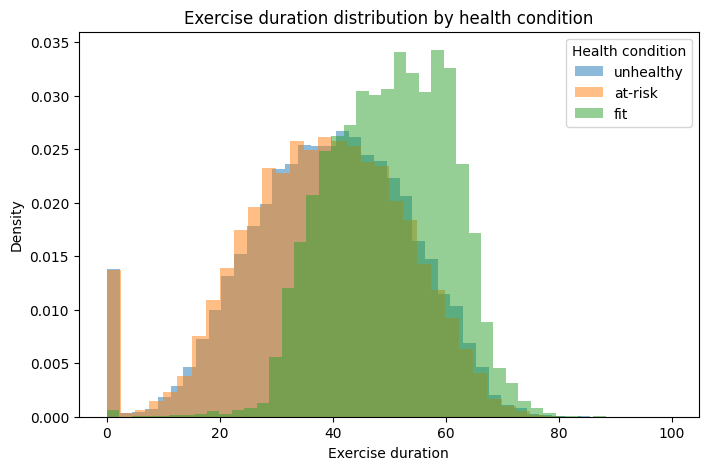

In [51]:
col = "exercise_duration"

plt.figure(figsize=(8, 5))

for label in train["health_condition"].unique():
    subset = train.loc[train["health_condition"] == label, col].dropna()
    plt.hist(subset, bins=40, alpha=0.5, density=True, label=label)

plt.title("Exercise duration distribution by health condition")
plt.xlabel("Exercise duration")
plt.ylabel("Density")
plt.legend(title="Health condition")
plt.show()

The histogram shows a visible spike at `exercise_duration = 0`, suggesting there is a distinct group of students with no recorded exercise. These rows are almost never labelled `fit`.

For feature engineering, I may test a `no_exercise` indicator:

df["no_exercise"] = (df["exercise_duration"] == 0).astype(int)

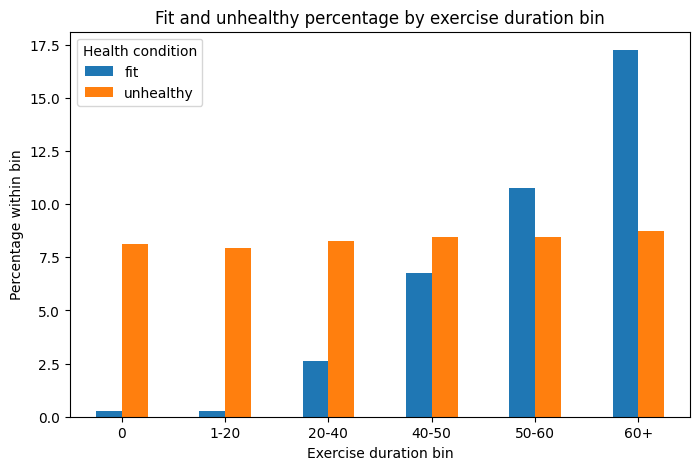

In [53]:
exercise_bin_target_percent[["fit", "unhealthy"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Fit and unhealthy percentage by exercise duration bin")
plt.xlabel("Exercise duration bin")
plt.ylabel("Percentage within bin")
plt.xticks(rotation=0)
plt.legend(title="Health condition")
plt.show()

The bin plot shows the clear trend with fit rising as exercise duration increases, and unhealthy staying constant.

In [55]:
temp_cols = ["step_count_bin", "exercise_duration_bin"]

train = train.drop(columns=[c for c in temp_cols if c in train.columns])

## Water intake

In [56]:
col = "water_intake"

water_summary = pd.DataFrame({
    "train": train[col].describe(),
    "test": test[col].describe()
})

display(water_summary)

,train,test
count,646611.000000,277120.000000
mean,2.188542,2.191508
std,0.518489,0.518771
min,0.500000,0.500000
25%,1.840000,1.850000
50%,2.170000,2.180000
75%,2.500000,2.500000
max,4.720000,4.720000


`water_intake` has very similar distributions in train and test, with no obvious distribution shift. Values range from 0.5 to 4.72, which looks reasonable.

In [57]:
water_by_target = train.groupby("health_condition")[col].describe()

display(water_by_target)

,count,mean,std,min,25%,50%,75%,max
health_condition,,,,,,,,
at-risk,555384.0,2.189130,0.517423,0.5,1.85,2.18,2.49,4.72
fit,37279.0,2.179176,0.530531,0.5,1.81,2.14,2.50,4.67
unhealthy,53948.0,2.188961,0.520977,0.5,1.84,2.18,2.51,4.72


`water_intake` does not appear to separate the target classes clearly. The mean, median, and quartiles are almost identical for `at-risk`, `fit`, and `unhealthy`.


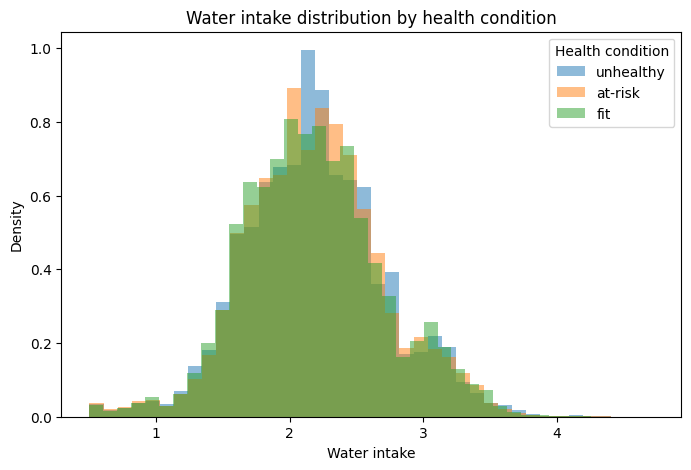

In [58]:
col = "water_intake"

plt.figure(figsize=(8, 5))

for label in train["health_condition"].unique():
    subset = train.loc[train["health_condition"] == label, col].dropna()
    plt.hist(subset, bins=40, alpha=0.5, density=True, label=label)

plt.title("Water intake distribution by health condition")
plt.xlabel("Water intake")
plt.ylabel("Density")
plt.legend(title="Health condition")
plt.show()

The histogram confirms that `water_intake` doesn't really separate the classes. For modelling, I will keep `water_intake`, but I do not expect it to be one of the strongest predictors on its own. It may still provide useful information through interactions with other features, such as `exercise_duration`, `step_count`, `diet_type`, or `bmi`.

# EDA Summary

## Categorical feature modelling summary

The categorical EDA suggests that several features are likely to be useful for modelling.

`stress_level` appears to be the strongest categorical predictor. It has a very strong relationship with the target and a natural order, so it is a strong candidate for ordinal encoding. Because the relationship is so strong, I may also check how much model performance depends on this feature.

`sleep_quality` also has a natural order and a clear relationship with the target. Poor sleep is associated with more `unhealthy` labels, while good sleep is associated with more `fit` labels. This feature is a candidate for ordinal encoding.

`physical_activity_level` is especially useful for identifying the minority `fit` class. Although it has a natural order, the main pattern seems to be `active` versus not active, so I may test a binary `is_active_lifestyle` feature.

`smoking_alcohol` has a weaker but still meaningful relationship with the target. It may be tested as either categorical or ordinal.

`diet_type` and `gender` have weaker relationships with the target. They are unlikely to be the strongest predictors on their own, but may still provide useful information in combination with other features.

For missing categorical values, I will generally avoid dropping rows. Missing values can be treated as their own category, and for selected columns I may also test missing-value indicators.

## Numerical feature summary

The numerical EDA suggests that several features are likely to be useful for modelling, but they seem to help with different parts of the classification problem.

`sleep_duration` appears to be the strongest numerical predictor. The `unhealthy` class tends to have much lower sleep duration, while the `fit` class tends to have higher sleep duration. The `at-risk` class sits between the two. This feature may help separate both minority classes, so I will keep the raw numerical feature and may later test threshold features such as low sleep duration or high sleep duration.

`bmi` also shows a useful relationship with the target. The `fit` class tends to have lower BMI, while the `unhealthy` class tends to have higher BMI. This may help separate `fit` and `unhealthy` students, especially when combined with lifestyle features such as `diet_type`, `physical_activity_level`, and `step_count`.

The activity-related numerical features — `step_count`, `exercise_duration`, and `calorie_expenditure` — are mainly useful for identifying the minority `fit` class. Higher values are associated with a higher percentage of `fit` labels, while the `unhealthy` percentage stays fairly stable. These features may work well alongside the categorical `physical_activity_level` feature.

`exercise_duration` also has a clear spike at zero. Students with zero recorded exercise are very rarely labelled `fit`, so I may later test a `no_exercise` indicator. I may also test high-activity threshold features such as high step count or high exercise duration.

`heart_rate` and `water_intake` show much weaker relationships with the target. Their distributions are very similar across the three health-condition classes. I will still keep them for modelling, but I do not expect them to be among the strongest predictors on their own. They may still provide small improvements through interactions with other features.

For numerical missing values, I will avoid dropping rows. I may use imputation for models that require complete data, and I may also test missing-value indicators for selected numerical features. For tree-based models that handle missing values directly, I may leave missing values as they are.

# Random Forest Baseline

Because the target classes are highly imbalanced, I will use stratified cross-validation. This keeps the class proportions similar in each fold.

The evaluation metric for the competition is balanced accuracy, so I will use `balanced_accuracy_score` during validation rather than ordinary accuracy.

For preprocessing, numerical features will be imputed with the median, while categorical features will be imputed with a missing category and one-hot encoded. One-hot encoding all categorical variables is a safe starting point because it avoids imposing an artificial order, especially for missing values. However, the EDA showed that some categorical features have a natural order, such as `stress_level`, `sleep_quality`, and `physical_activity_level`. After the first baseline, I will test an alternative preprocessing approach where these features are ordinal encoded and compare the cross-validation balanced accuracy.

This preprocessing is placed inside a pipeline so that each cross-validation fold is handled correctly without data leakage.

## Separate X and y

In [59]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

In [60]:
X = train.drop(columns=["id", "health_condition"])
y = train["health_condition"]

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']
Categorical features: ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


## Build preprocessing pipeline

In [64]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Random Forest Pipeline

In [66]:
rf_params = {
    "n_estimators": 100,
    "max_depth": 12,
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1
}

rf_model = RandomForestClassifier(**rf_params)

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

## Stratified Cross-Validation

In [67]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=cv,
    scoring="balanced_accuracy",
    n_jobs=-1
)

print("Balanced accuracy scores:", cv_scores)
print("Mean balanced accuracy:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

Balanced accuracy scores: [0.9462413  0.94671055 0.94543344 0.94574483 0.94276591]
Mean balanced accuracy: 0.9453792070267323
Standard deviation: 0.001377069408868247


## Random Forest cross-validation results

The Random Forest baseline performs strongly, with a mean cross-validation balanced accuracy of approximately 0.945. The scores are also stable across folds, with a low standard deviation.

Because the target is highly imbalanced, I will inspect class-level recall and the confusion matrix next. This is important because a high overall score is only useful if the model is identifying the minority `fit` and `unhealthy` classes, not just the majority `at-risk` class.

In [68]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix

oof_preds = cross_val_predict(
    rf_pipeline,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

print("OOF balanced accuracy:", balanced_accuracy_score(y, oof_preds))
print()
print(classification_report(y, oof_preds, digits=4))

OOF balanced accuracy: 0.9453792881941908

              precision    recall  f1-score   support

     at-risk     0.9911    0.9470    0.9686    592561
         fit     0.7320    0.9486    0.8263     39803
   unhealthy     0.7508    0.9405    0.8350     57724

    accuracy                         0.9466    690088
   macro avg     0.8246    0.9454    0.8766    690088
weighted avg     0.9561    0.9466    0.9492    690088



In [69]:
from sklearn.model_selection import cross_val_predict

oof_probas = cross_val_predict(
    rf_pipeline,
    X,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)

oof_probas.shape

(690088, 3)

In [70]:
labels = ["at-risk", "fit", "unhealthy"]

cm = confusion_matrix(y, oof_preds, labels=labels)
cm_percent = confusion_matrix(y, oof_preds, labels=labels, normalize="true") * 100

cm_df = pd.DataFrame(cm, index=labels, columns=labels)
cm_percent_df = pd.DataFrame(cm_percent, index=labels, columns=labels)

display(cm_df)
display(cm_percent_df.round(2))

,at-risk,fit,unhealthy
at-risk,561168,13539,17854
fit,1879,37756,168
unhealthy,3147,285,54292


,at-risk,fit,unhealthy
at-risk,94.70,2.28,3.01
fit,4.72,94.86,0.42
unhealthy,5.45,0.49,94.05


The Random Forest baseline performs strongly across all three classes. The mean cross-validation balanced accuracy is approximately 0.945, and the class-level recalls are all around 94–95%.

This is important because the target is highly imbalanced. The model is not simply predicting the majority `at-risk` class; it is also identifying the minority `fit` and `unhealthy` classes well.

The precision for `fit` and `unhealthy` is lower than for `at-risk`, which means the model sometimes over-predicts the minority classes. This is a reasonable trade-off for this competition because the evaluation metric is balanced accuracy, which rewards recall across all classes.

The confusion matrix shows that most errors involve confusing `fit` or `unhealthy` with `at-risk`, or predicting some `at-risk` rows as one of the minority classes. Overall, the baseline is strong and gives a useful benchmark for future feature engineering and model tuning.

# Submission

Train the final model on all the training data:

In [71]:
rf_pipeline.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['sleep_duration',
                                                   'heart_rate', 'bmi',
                                                   'calorie_expenditure',
                                                   'step_count',
                                                   'exercise_duration',
                                                   'water_intake']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['diet_type', 'stress_level',
                                                   'sleep_quality',
                                                   'physical_activity_level',
                                                   'smoking_alcohol',
                                                   'gender'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=12,
                                        n_jobs=-1, random_state=42))])

Predict the test labels:

In [73]:
X_test = test.drop(columns=["id"])
test_preds = rf_pipeline.predict(X_test)

test_preds[:10]

array(['unhealthy', 'unhealthy', 'at-risk', 'at-risk', 'unhealthy', 'fit',
       'at-risk', 'at-risk', 'at-risk', 'at-risk'], dtype=object)

In [74]:
pd.Series(test_preds).value_counts(normalize=True)

at-risk      0.822396
unhealthy    0.104212
fit          0.073392
Name: proportion, dtype: float64

Create the submission:

In [75]:
submission = sample_sub.copy()
submission["health_condition"] = test_preds

submission.head()

,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


In [77]:
submission.to_csv("rf_one_hot_encoding_submission.csv", index=False)

# Feature Importances

In [78]:
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipeline.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(feature_importance.head(30))

,feature,importance
0,num__sleep_duration,0.302790
13,cat__stress_level_low,0.166571
12,cat__stress_level_high,0.134816
14,cat__stress_level_medium,0.103175
20,cat__physical_activity_level_active,0.084821
21,cat__physical_activity_level_moderate,0.037492
22,cat__physical_activity_level_sedentary,0.032011
11,cat__stress_level_Missing,0.029478
2,num__bmi,0.026856
5,num__exercise_duration,0.020964


In [79]:
def get_original_feature(transformed_name):
    name = transformed_name.split("__", 1)[1]
    
    for col in categorical_features:
        if name == col or name.startswith(col + "_"):
            return col
    
    return name

feature_importance["original_feature"] = feature_importance["feature"].apply(get_original_feature)

grouped_importance = (
    feature_importance
    .groupby("original_feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

display(grouped_importance)

,original_feature,importance
11,stress_level,0.434040
7,sleep_duration,0.302790
6,physical_activity_level,0.160388
0,bmi,0.026856
3,exercise_duration,0.020964
8,sleep_quality,0.018489
10,step_count,0.016582
9,smoking_alcohol,0.008911
1,calorie_expenditure,0.004527
5,heart_rate,0.002345


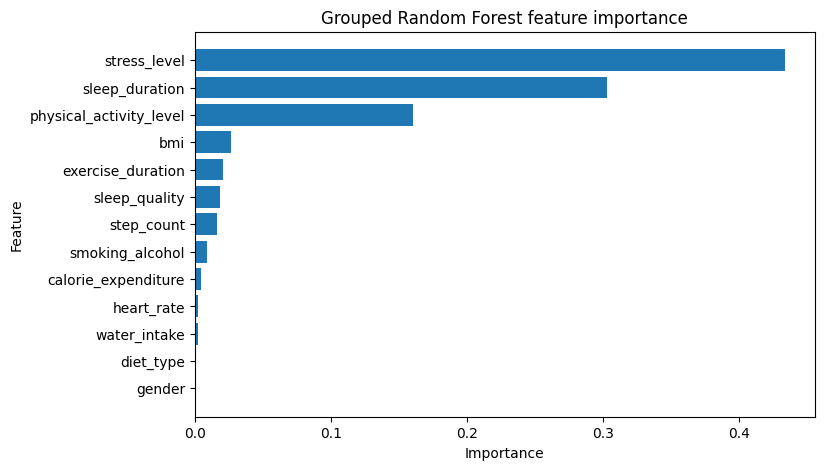

In [80]:
plt.figure(figsize=(8, 5))

plt.barh(
    grouped_importance["original_feature"],
    grouped_importance["importance"]
)

plt.gca().invert_yaxis()
plt.title("Grouped Random Forest feature importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

The Random Forest feature importances support the main findings from the EDA.

The most important grouped feature is `stress_level`, which accounts for the largest share of model importance. This matches the categorical EDA, where `stress_level` showed a very strong relationship with the target.

`sleep_duration` is the most important numerical feature. This also matches the numerical EDA, where lower sleep duration was associated with `unhealthy` students and higher sleep duration was associated with `fit` students.

`physical_activity_level` is the next most important feature. This supports the earlier finding that activity-related features are especially useful for identifying the minority `fit` class.

Other features such as `bmi`, `exercise_duration`, `step_count`, and `sleep_quality` still contribute to the model, but their importance is much lower. Features such as `gender`, `diet_type`, `water_intake`, and `heart_rate` have very low importance in this Random Forest baseline, which matches the EDA where these variables showed weaker relationships with the target.

Overall, the model is mostly relying on three groups:  
* stress_level                 0.434  
* sleep_duration               0.303  
* physical_activity_level      0.160  

These add up to nearly 90% of the total importance.

# Save OOF probabilities for later ensembling

In [ ]:
test_probas = rf_pipeline.predict_proba(X_test)

test_probas.shape

In [ ]:
class_labels = np.unique(y)
np.save(artifact_dir / "train_oof_rf_v1_proba.npy", oof_probas)
np.save(artifact_dir / "test_rf_v1_proba.npy", test_probas)
np.save(artifact_dir / "class_labels_rf_v1.npy", class_labels)

In [ ]:
oof_proba_df = pd.DataFrame(oof_probas, columns=class_labels)
test_proba_df = pd.DataFrame(test_probas, columns=class_labels)

oof_proba_df.to_csv(artifact_dir / "train_oof_rf_v1_proba.csv", index=False)
test_proba_df.to_csv(artifact_dir / "test_rf_v1_proba.csv", index=False)

In [ ]:
experiment_log = pd.DataFrame({
    "experiment": ["rf_v1"],
    "model": ["RandomForestClassifier"],
    "cv_score": [0.9453792070267323],
    "public_score": [0.94671],
    "notes": ["One-hot categorical encoding, median numeric imputation, class_weight='balanced', max_depth=12, n_estimators=100"]
})

experiment_log.to_csv(artifact_dir / "experiment_log_rf_v1.csv", index=False)

experiment_log

In [ ]:
list(artifact_dir.iterdir())

## Zip model artifacts for download

The OOF probabilities, test probabilities, class labels, and experiment log have been saved in `/kaggle/working/model_artifacts/rf_v1`.

I will zip these files so they can be downloaded easily from the Kaggle notebook output.

In [ ]:
import shutil
from pathlib import Path

artifact_dir = Path("/kaggle/working/model_artifacts/rf_v1")

zip_path = shutil.make_archive(
    base_name="/kaggle/working/rf_v1_artifacts",
    format="zip",
    root_dir=artifact_dir
)

zip_path